# Tufa Labs ARC3 submission

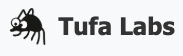

**Note**: this notebook is a more readable version of the notebook that scored our milestone-winning 1.21; unfortunately, we haven't had the same lucky result with this one. The original one is also shared here, but using it is not recommended: https://www.kaggle.com/code/jeroencottaar/taaf-duck-harness-kaggle

**Note**: if you make a copy of this notebook, you will have to manually select the proper GPU (RTX Pro 6000).

Link to writeup explaining what's going on here: https://www.kaggle.com/competitions/arc-prize-2026-arc-agi-3/discussion/717133

Link to Machine Learning Street Talk interview by Tim Scarfe about this duck harness: https://x.com/MLStreetTalk/status/2072326433922297975?s=20

This notebook executes the ARC-AGI-3 solver written by the Tufa Labs team; in alphabetical order: Harold Bessis, Jeroen Cottaar, Isaiah Pressman, Andries Smit, Michal Tesnar, and Stefano Viel.

You will only find infrastructure and diagnostics in this notebook; the actual solver code is in an attached dataset. See our writeup on the competition forum to learn more about that the solver actually does.

It installs the ARC runtime from the competition wheelhouse, makes the bundled source
snapshot importable, runs any solver setup commands, loads the pickled benchmark, plays the
competition games, and writes results to `/kaggle/working`. Diagnostics are minimised during
a real competition rerun (`KAGGLE_IS_COMPETITION_RERUN`) and kept full otherwise.

## 1. Environment and submission mode

Detect whether this is a real competition rerun (which minimises diagnostics), set the
framework's environment flags, and put the CUDA libraries on the linker path.

In [ ]:
import json
import os
import pickle
import subprocess
import sys
import sysconfig
import time
from datetime import datetime, timedelta
from pathlib import Path
from urllib.request import urlopen

# True only inside a real competition rerun; switches diagnostics + soft deadline.
TRUE_SUBMISSION = os.environ.get("KAGGLE_IS_COMPETITION_RERUN", "").strip().lower() in {"1", "true"}
NOTEBOOK_START_EPOCH = time.time()

# Non-interactive matplotlib backend: diagnostics render plots with no display attached.
os.environ["MPLBACKEND"] = "Agg"
# Marks the run as a (real or emulated) submission so the framework + solver can adjust.
os.environ["TAAF_RUN_AS_SUBMISSION"] = "1" if TRUE_SUBMISSION else "0"
# In submission, disable the periodic JSON/HTML diagnostics writes and per-frame logging.
os.environ["TAAF_MINIMAL_DIAGNOSTICS"] = "1" if TRUE_SUBMISSION else "0"
# Pin arc_agi's cached level_reset_only before its client is built (RESET keeps the level).
os.environ["ONLY_RESET_LEVELS"] = "true"

# Prepend the CUDA toolkit to the linker path (it is off it on Kaggle GPU images) so the
# solver's GPU libraries (e.g. vllm / torch) can link against libcuda.
cuda_library_path = "/usr/local/nvidia/lib64"
os.environ["LIBRARY_PATH"] = os.pathsep.join(
    entry for entry in [cuda_library_path, *os.environ.get("LIBRARY_PATH", "").split(os.pathsep)] if entry
)

# Everything the run produces is written here.
WORKING_DIR = Path("/kaggle/working")
WORKING_DIR.mkdir(parents=True, exist_ok=True)
print(f"taaf.kaggle: TRUE_SUBMISSION={TRUE_SUBMISSION}")

## 2. Install the ARC runtime

Install `arc-agi` from the offline competition wheelhouse (the Kaggle submission environment
has no internet).

In [ ]:
# Install the ARC runtime from the bundled competition wheels.
# Quiet: stdout is discarded; stderr (and a non-zero exit) still surface real failures.
subprocess.check_call(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--quiet",
        "--no-index",
        "--no-warn-conflicts",
        "--disable-pip-version-check",
        "--find-links",
        "/kaggle/input/competitions/arc-prize-2026-arc-agi-3/arc_agi_3_wheels",
        "arc-agi",
    ],
    stdout=subprocess.DEVNULL,
)

## 3. Locate the source bundle

Find the uploaded TAAF source dataset by its marker file, and record where Kaggle mounted
every attached input so setup commands and the solver can find them.

In [ ]:
# Kaggle inputs attached to this notebook, plus bookkeeping paths used below.
DATASET_SOURCES = ["thtennant/taaf-kaggle-source-share-fork", "driessmit1/arc3-vllm-h100-wheelhouse-v3", "driessmit1/vrfai-qwen3-6-27b-fp8-hf-snapshot"]
KERNEL_SOURCES = []
DATASET_BUNDLE_MARKER = "taaf-kaggle-bundle.json"
SETUP_ENV_PATH = WORKING_DIR / "taaf_setup_env.json"


# Locate the source dataset by its marker file rather than a fixed mount path.
def _find_bundle_dir() -> Path:
    for marker in Path("/kaggle/input").rglob(DATASET_BUNDLE_MARKER):
        return marker.parent
    raise RuntimeError("TAAF source bundle not found under /kaggle/input.")


# Kaggle mounts a dataset at /kaggle/input/<slug> or /kaggle/input/datasets/<owner>/<slug>
# (depending on owner / slug collisions), so probe both and use whichever exists. Utility
# scripts mount under /kaggle/usr/lib/notebooks/<owner>/<slug>.
def _dataset_mount_candidates(ref: str) -> list[Path]:
    owner, slug = ref.split("/", 1)
    return [Path("/kaggle/input") / slug, Path("/kaggle/input/datasets") / owner / slug]


def _kernel_mount_candidates(ref: str) -> list[Path]:
    owner, slug = ref.split("/", 1)
    return [Path("/kaggle/usr/lib/notebooks") / owner / slug]


def _first_existing(candidates: list[Path]) -> Path | None:
    return next((c for c in candidates if c.exists()), None)


BUNDLE_DIR = _find_bundle_dir()
print(f"taaf.kaggle: source bundle = {BUNDLE_DIR}")

# Map each attached input to where Kaggle actually mounted it (the source bundle is index 0).
kaggle_input_paths: dict[str, str] = {}
for i, ref in enumerate(DATASET_SOURCES):
    candidates = _dataset_mount_candidates(ref)
    resolved = BUNDLE_DIR if i == 0 else _first_existing(candidates)
    kaggle_input_paths[ref] = str(resolved or candidates[0])
for ref in KERNEL_SOURCES:
    candidates = _kernel_mount_candidates(ref)
    kaggle_input_paths[ref] = str(_first_existing(candidates) or candidates[0])

# Published to setup commands and the solver via the environment:
setup_env = {
    # JSON {ref: mount_path} so they can locate every attached dataset / utility script.
    "TAAF_KAGGLE_INPUT_PATHS": json.dumps(kaggle_input_paths, sort_keys=True),
    # The attached dataset refs in order (index 0 is this source bundle).
    "TAAF_KAGGLE_DATASET_SOURCES": json.dumps(DATASET_SOURCES),
    # The attached utility-script / kernel refs.
    "TAAF_KAGGLE_KERNEL_SOURCES": json.dumps(KERNEL_SOURCES),
}
os.environ.update(setup_env)
SETUP_ENV_PATH.write_text(json.dumps(setup_env, indent=2, sort_keys=True) + "\n")
print(f"taaf.kaggle: input paths = {setup_env['TAAF_KAGGLE_INPUT_PATHS']}")

## 4. Import the bundled source and run solver setup

Put the snapshotted repositories on the path (this process and any child processes), then run
the solver's setup commands — installing wheels, fetching model weights, and so on.

In [ ]:
# Each bundled repo exposes its importable tree at <repo>/src or <repo>.
def _source_path_entries(bundle_dir: Path) -> list:
    entries = []
    for repo in sorted((bundle_dir / "src").iterdir(), reverse=True):
        for candidate in (repo / "src", repo):
            if candidate.is_dir():
                entries.append(candidate)
    return entries


# Environment handed to each setup command (paths + any keys it has persisted).
def _command_env() -> dict:
    env = os.environ.copy()
    # "$PYTHON" in a command resolves to this notebook's interpreter.
    env["PYTHON"] = sys.executable
    # Absolute path to the mounted source bundle.
    env["TAAF_KAGGLE_BUNDLE_DIR"] = str(BUNDLE_DIR)
    # The writable /kaggle/working directory.
    env["TAAF_KAGGLE_WORKING_DIR"] = str(WORKING_DIR)
    # A command writes a JSON object here to persist env keys to later commands + the run.
    env["TAAF_KAGGLE_SETUP_ENV"] = str(SETUP_ENV_PATH)
    env.update({str(k): str(v) for k, v in json.loads(SETUP_ENV_PATH.read_text()).items()})
    return env


# Make the bundled repos importable here (sys.path) and in child processes (.pth).
source_entries = _source_path_entries(BUNDLE_DIR)
for entry in source_entries:
    sys.path.insert(0, str(entry))
pth_path = Path(sysconfig.get_paths()["purelib"]) / "taaf_kaggle_sources.pth"
pth_path.write_text("".join(f"{entry}\n" for entry in source_entries))
print(f"taaf.kaggle: wrote {pth_path} ({len(source_entries)} source roots)")

# Solver setup commands (wheels, vLLM server startup, ...) run before the benchmark loads.
env = _command_env()
for command in json.loads((BUNDLE_DIR / "setup_commands.json").read_text()):
    print(f"taaf.kaggle: setup command: {command}", flush=True)
    subprocess.run(command, shell=True, check=True, cwd=WORKING_DIR, env=env)
    # Re-read in case the command persisted new env keys.
    env = _command_env()
    os.environ.update(env)

# Honour any PYTHONPATH a setup command exported.
for entry in reversed([e for e in os.environ.get("PYTHONPATH", "").split(os.pathsep) if e]):
    if entry not in sys.path:
        sys.path.insert(0, entry)

## 5. Load the benchmark

Unpickle the deployment target and the benchmark, stamping the real submission state onto the
target and pointing the benchmark's outputs at the Kaggle working directory.

In [ ]:
# Restore the deployment target and record the real submission state on it.
with open(BUNDLE_DIR / "deploy_target.pkl", "rb") as file:
    target = pickle.load(file)
target.actual_run_as_submission = TRUE_SUBMISSION
target.is_competition_rerun = TRUE_SUBMISSION

# Restore the benchmark and point its outputs at the Kaggle working dir.
with open(BUNDLE_DIR / "benchmark_initial.pkl", "rb") as file:
    bm = pickle.load(file)
bm.job_dir = WORKING_DIR

## 6. Customization hook

Optional: tweak `bm`, `bm.games`, or `bm.solver` here before the run starts — the safe place
for one-off experiments once the deployed bundle has loaded.

In [ ]:
# Make one-off changes to `bm`, `bm.games`, or `bm.solver` here before the run starts.
# Example:
# bm.label = f"{bm.label}-debug"

# Composite graft install (v12): the single cell-12 entry point shipped in our
# forked source bundle (thtennant/taaf-kaggle-source-share-fork, src/taaf-grafts),
# importable here because the source-import cell above put every bundled repo on
# sys.path. install(bm, flags) wires the EfficiencyToolAgent analyzer (budget-aware
# per-turn note + net-zero waste detection, report-only) plus the RetryGuard
# analyzer chain layer (a proven pass-through rider) plus shortcircuit (no-op
# overshoot trimmer), printing the machine-parseable
# 'TAAF_GRAFTS FEATURES={...} API_VERSION=1' banner the commit-log gate reads.
# The run cell below reassigns bm.games (offline dup-game gate included) but never
# touches bm.solver, so swapping the solver instance here is safe: Benchmark.run
# deepcopies whatever solver is present at run time.
# install() is itself blanket-guarded (restores the original bm.solver on ANY
# error); the extra try/except-pass here is belt-and-suspenders so even an import
# failure of composite leaves bm.solver untouched (stock HarnessSolver).

# The flags live here and nowhere else, which made the project's most expensive
# measurement unattributable: two runs of this notebook scored 1.36 and 10.71 on the
# same game (tn36, both 2 of 7 levels) on identical repo commits and byte-identical
# taaf_setup_env.json, and there is no record of what either one had switched on.
# Note especially that "context_window" is applied in-process and therefore does NOT
# appear in taaf_setup_env.json, which reports the env var (32768) for every run
# regardless of what the graft actually used - so the one knob most suspected of
# causing wasted actions is precisely the one the artifact bundle is blind to.
# GRAFT_FLAGS is written to /kaggle/working below so the next expensive run answers
# the question instead of posing it.
GRAFT_FLAGS = {"efficiency": True, "retry_guard": True, "shortcircuit": True, "context_window": 57344}

try:
    from taaf_grafts.composite import install

    install(bm, flags=GRAFT_FLAGS)
except Exception as exc:  # noqa: BLE001 — any graft failure must fall back to stock
    print(f"[taaf_grafts] cell-12 graft failed, running stock: {type(exc).__name__}: {exc}")
    GRAFT_FLAGS = {"_install_failed": f"{type(exc).__name__}: {exc}"}

# Record what this run actually configured, next to the other artifacts. Wrapped
# because a diagnostics write must never be able to sink a nine-hour run.
try:
    (WORKING_DIR / "graft_flags.json").write_text(json.dumps(GRAFT_FLAGS, indent=2, sort_keys=True) + "\n")
    print(f"taaf.kaggle: graft flags = {json.dumps(GRAFT_FLAGS, sort_keys=True)}")
except Exception as exc:  # noqa: BLE001
    print(f"[taaf_grafts] could not persist graft flags: {type(exc).__name__}: {exc}")


## 6b. Session grafts — level probe + family priors

Two independent grafts, added 2026-08-23. Each is wrapped so that **any** failure
leaves the stock path untouched, and each is reported by name below so the run log
says which ones actually installed.

**A. Level probe (inert).** `taaf.game.Game.finish_game` already computes
`actions_per_level` and `base_actions_per_level`; a true submission sets
`TAAF_MINIMAL_DIAGNOSTICS=1` and never persists them. This appends one JSON line per
finished game to `/kaggle/working/level_probe.jsonl`. It reads values the framework
has already filled in, so it cannot change what the solver does. It exists because
a score of 2.14 is equally consistent with *level 0 on most games* and *two levels
on a handful*, and those two states need opposite fixes.

**B. Family priors (behavioural).** Appends one addendum to the agent's system
prompt, carrying two findings that generalise beyond any single game:

1. *The goal is usually drawn on frame 0.* Across the readable dev games, 10 of 13
   win conditions are one predicate — every object of kind A co-located with an
   object of kind B — and kind B is on the board before the first action, as a set
   of small, identical, static objects. The agent already has each object's shape
   hash from `segmentation`; it was never told what to look for with it.
2. *Efficiency only costs score where you clear.* Level score is
   `(baseline/actions)²`, awarded only for cleared levels, so actions on a level you
   never clear are free — explore level 0, execute crisply later, and never give up
   early.

Prior 2 is measured from this notebook's own event log; prior 1 was read from the
25 dev games' source. Both are stated as defaults that evidence from the live game
overrides.

In [ ]:
# --- session grafts, 2026-08-23 -----------------------------------------------
# A: level probe (inert instrumentation).  B: family priors (system-prompt text).
# Both blanket-guarded: on ANY exception the stock 2.14 behaviour is what runs.
# Set either flag to False to ship without it.
INSTALL_LEVEL_PROBE = True
INSTALL_FAMILY_PRIORS = True

LEVEL_PROBE_PATH = WORKING_DIR / "level_probe.jsonl"


# --- Graft A: one JSON line per finished game --------------------------------
# `Game.finish_game` (taaf/game.py:596) already fills in every field read here and
# prints them at 645-650; TAAF_MINIMAL_DIAGNOSTICS=1 is why a real submission keeps
# no artifact of them. Appending is O(1) per game, ~110 lines over nine hours.
def _install_level_probe() -> str:
    import taaf.game

    game_cls = taaf.game.Game
    if getattr(game_cls.finish_game, "_level_probe", False):
        return "already installed"
    original = game_cls.finish_game

    def finish_game(self, generated_tokens: int = 0, uncached_input_tokens: int = 0) -> None:
        # finish_game is idempotent by an early return on final_score (game.py:615),
        # so it can legitimately be called twice; only the call that actually scores
        # the game should emit a row.
        run_before = getattr(self, "game_run", None)
        first_call = run_before is not None and run_before.final_score is None
        original(self, generated_tokens=generated_tokens, uncached_input_tokens=uncached_input_tokens)
        if not first_call:
            return
        try:
            run = self.game_run
            base = run.base_actions_per_level
            row = {
                "game_id": run.game_id,
                "state": run.state,
                "levels_completed": run.levels_completed,
                "number_of_levels": run.number_of_levels,
                "final_score": run.final_score,
                "actions_per_level": list(run.actions_per_level),
                # None here means the framework hit its documented silent fallback
                # (game_api.py:232) and every efficiency ratio in the run is unusable.
                "base_actions_per_level": list(base) if base is not None else None,
                "wallclock_s": round(float(run.final_wallclock_seconds or 0.0), 1),
                "turns": len(run.history),
                "generated_tokens": sum(r.generated_tokens for r in run.history) + run.final_generated_tokens,
                "note": run.solver_note,
            }
            with open(LEVEL_PROBE_PATH, "a", encoding="utf-8") as handle:
                handle.write(json.dumps(row, default=str) + "\n")
        except Exception as exc:  # noqa: BLE001 — a diagnostics write must never sink the run
            print(f"[graft] level probe row failed: {type(exc).__name__}: {exc}")

    finish_game._level_probe = True
    game_cls.finish_game = finish_game
    return f"wrapped taaf.game.Game.finish_game -> {LEVEL_PROBE_PATH}"


# --- Graft B: the two family priors ------------------------------------------
# Phrased as defaults rather than rules, and grounded in what the agent can already
# see: `segmentation` gives every object a colour+shape hash (prompts.py:43), which
# is exactly the key that groups "several identical things drawn on the board".
FAMILY_PRIORS_ADDENDUM = """

# Two priors about this family of games

These hold across the family these puzzles are drawn from, not just this one. Treat
them as strong starting defaults: evidence from THIS game always overrides them.

## 1. The goal is usually already drawn on the first frame

In most of these games the win condition is a *cover* predicate:

    every object of kind A must end up co-located with an object of kind B.

Kind B is on the board before you take a single action, and it looks like this: a
group of two or more objects that are (a) identical to each other, so same colour
and same shape and therefore the same segmentation hash, (b) small, because they
mark a place rather than being scenery or wall, and (c) static, because they do not
move when you act. Kind A is what you move or push.

So in your first turns, before experimenting: group the segmentation nodes of the
current frame by hash. Any group of 2 or more small identical shapes is a candidate
destination set, and the size of that group tells you how many things you probably
have to deliver. That reframes the game from "what does this button do" to "get
each mover onto one destination" - and it means you can often read the objective
off the board instead of inferring it from a reward you have not seen yet.

Recognise the variants:
- the destination may be a single object, not a group, so a lone small static shape
  distinct from everything else is also a candidate;
- the predicate may be at pixel level - a workspace region must be made equal to a
  reference region drawn elsewhere on the board, in which case your progress meter
  is the count of mismatched pixels between the two;
- it may be "remove every object of colour X", in which case the remaining count of
  X is your progress meter;
- it may be ordered, so covering the destinations in the wrong sequence undoes
  earlier progress.

If the first frame has no repeated small static group and no distinct lone marker,
this prior does not apply - fall back to experimenting.

## 2. Where being efficient actually pays, and where it does not

A level scores (baseline_actions / your_actions) squared, and it scores that ONLY if
you clear it. A level you never clear contributes zero no matter what you did on it,
so the actions you spent there cost you nothing.

Two consequences, and they point in opposite directions:

- Exploring is cheap on the first level, and free on any level you end up not
  clearing. Spend actions to establish the mechanics: which button moves what, what
  blocks movement, what the objective is, what an action does when nothing appears
  to change. The first level also carries the smallest weight of any level in the
  game.
- Being crisp pays on later levels. Once you know the mechanics, execute. Later
  levels carry more weight and charge every wasted action quadratically, and you
  should re-derive nothing you already established earlier in the same game - the
  mechanics do not change between levels, only the layout does.

And never stop trying because you have used a lot of actions. Exhausting your
actions on a level you cannot solve costs exactly zero, so there is no situation in
which giving up scores better than continuing to try.
"""


def _install_family_priors() -> str:
    import inference.agent.tool_agent as tool_agent

    original = tool_agent._build_system_prompt
    if getattr(original, "_family_priors", False):
        return "already installed"

    def _build_system_prompt(*, tool_output_tokens: int) -> str:
        return original(tool_output_tokens=tool_output_tokens) + FAMILY_PRIORS_ADDENDUM

    _build_system_prompt._family_priors = True
    # benchmark.py plays games with asyncio.create_task in this same process
    # (benchmark.py:163-199), and tool_agent.py:941 resolves this name from module
    # globals at call time, so rebinding the module attribute reaches every game.
    tool_agent._build_system_prompt = _build_system_prompt
    return f"appended {len(FAMILY_PRIORS_ADDENDUM)} chars to the agent system prompt"


SESSION_GRAFTS = {}
for _name, _enabled, _installer in [
    ("level_probe", INSTALL_LEVEL_PROBE, _install_level_probe),
    ("family_priors", INSTALL_FAMILY_PRIORS, _install_family_priors),
]:
    if not _enabled:
        SESSION_GRAFTS[_name] = "disabled"
        continue
    try:
        SESSION_GRAFTS[_name] = _installer()
    except Exception as exc:  # noqa: BLE001 — any graft failure falls back to stock
        SESSION_GRAFTS[_name] = f"FAILED {type(exc).__name__}: {exc}"
    print(f"[graft] {_name}: {SESSION_GRAFTS[_name]}")

# Record what this run configured, next to graft_flags.json, so the result is
# attributable — the single lesson from two runs that scored 1.36 and 10.71 on the
# same game with no record of what differed.
try:
    (WORKING_DIR / "session_grafts.json").write_text(json.dumps(SESSION_GRAFTS, indent=2, sort_keys=True) + "\n")
except Exception as exc:  # noqa: BLE001
    print(f"[graft] could not persist session graft status: {type(exc).__name__}: {exc}")

## 7. Run the benchmark

In a real competition rerun (`KAGGLE_IS_COMPETITION_RERUN`), wait for the Kaggle gateway and
play the **live competition Arcade**. Otherwise — an interactive "Save & Run" — play the
competition's **bundled environment files offline**, with no gateway required, so the notebook
runs end-to-end without a submission. Teardown commands run afterward even if the run raises.

In [ ]:
# Build the live competition game list from the gateway's available environments.
def _competition_games():
    import arc_agi

    import taaf.game_api

    spec = taaf.game_api.ArcadeSpec(
        operation_mode=arc_agi.OperationMode.COMPETITION,
        arc_base_url=os.environ["ARC_BASE_URL"],
        environments_dir="",
    )
    arcade = arc_agi.Arcade(
        operation_mode=arc_agi.OperationMode.COMPETITION,
        arc_base_url=spec.arc_base_url,
        environments_dir="",
    )
    game_ids = [env_info.game_id for env_info in arcade.available_environments]
    if not game_ids:
        raise RuntimeError("Competition Arcade exposed zero environments.")
    return [taaf.game_api.GameAPI(env_name=game_id, arcade_spec=spec) for game_id in game_ids]


# Build the offline game list from the competition's bundled environment files.
def _offline_games(env_dir: str):
    import arc_agi

    import taaf.game_api

    spec = taaf.game_api.ArcadeSpec(operation_mode=arc_agi.OperationMode.OFFLINE, environments_dir=env_dir)
    arcade = arc_agi.Arcade(operation_mode=arc_agi.OperationMode.OFFLINE, environments_dir=env_dir)
    game_ids = [env_info.game_id for env_info in arcade.available_environments]
    if not game_ids:
        raise RuntimeError(f"No offline environments found under {env_dir}.")
    return [taaf.game_api.GameAPI(env_name=game_id, arcade_spec=spec) for game_id in game_ids]


# The gateway can take a while to come up; poll until it answers.
def _wait_for_gateway(base_url: str, timeout_s: float = 600.0) -> None:
    deadline = time.monotonic() + timeout_s
    last_error = ""
    while time.monotonic() < deadline:
        try:
            with urlopen(f"{base_url}api/games", timeout=10) as response:
                if response.status < 500:
                    return
        except Exception as exc:
            last_error = repr(exc)
        time.sleep(5)
    raise RuntimeError(f"Kaggle gateway did not become ready: {last_error}")


# Print the run preamble and persist the launcher's git status for diagnostics.
print((BUNDLE_DIR / "preamble.txt").read_text())
(WORKING_DIR / "git_status.txt").write_text((BUNDLE_DIR / "git_status.txt").read_text())

# arc_agi reads RECORDINGS_DIR and ARC_API_KEY from env (ArcadeSpec carries neither); operation
# mode, environments dir, and base url are all passed explicitly via the spec, so no env is needed.
os.environ.setdefault("RECORDINGS_DIR", str(WORKING_DIR / "server_recording"))

if TRUE_SUBMISSION:
    # Real submission: play the live competition Arcade served by the Kaggle gateway.
    os.environ.setdefault("ARC_API_KEY", "test-key-123")
    os.environ.setdefault("ARC_BASE_URL", "http://gateway:8001/")
    # The gateway boots asynchronously; wait before swapping in its game list.
    _wait_for_gateway(os.environ["ARC_BASE_URL"])
    bm.games = _competition_games()
else:
    # Interactive run: play the bundled competition environments offline (no gateway).
    # The competition's environment files ship alongside the wheelhouse in the competition dataset.
    competition_env_files = str(Path("/kaggle/input/competitions/arc-prize-2026-arc-agi-3/arc_agi_3_wheels").parent / "environment_files")
    bm.games = _offline_games(competition_env_files)

# Safety pack + dup-game commit gate: keep interactive commit runs short AND make
# the transfer family store fire. Provably inert in a real rerun (guarded on
# TRUE_SUBMISSION); it must live in this cell, after the branches above, because
# both branches reassign bm.games (cell 12 runs first). The duplicate is the SAME
# env as games[0] added via GameAPI.external_game_id (game_api.py:155) — Benchmark's
# unique-game_id check (benchmark.py:160) is satisfied because the dup carries a
# distinct game_id, while the shared arcade_spec keeps it in games[0]'s fingerprint
# family: games[0] scouts and publishes, the dup replays. Any construction fault
# falls back to the plain [:4] truncation.
if not TRUE_SUBMISSION:
    try:
        import taaf.game_api

        first = bm.games[0]
        bm.games = bm.games[:3] + [
            taaf.game_api.GameAPI(
                env_name=first.env_name,
                arcade_spec=first.arcade_spec,
                external_game_id=f"{first.env_name}-dup",
            )
        ]
    except Exception as exc:  # noqa: BLE001 — any dup fault falls back to plain truncation
        print(f"[taaf_grafts] dup-game gate failed, using [:4]: {type(exc).__name__}: {exc}")
        bm.games = bm.games[:4]

bm.n_passes = 1
bm.game_weights = None

# Outside a real submission, stop ~10 min before the wall-clock budget for a graceful exit.
soft_end = None
if not TRUE_SUBMISSION:
    budget = float(getattr(target, "max_runtime_s", 0.0) or 0.0)
    if budget > 0:
        soft_end = datetime.fromtimestamp(NOTEBOOK_START_EPOCH) + timedelta(seconds=budget - min(600.0, budget / 2))
else:
    # Safety pack: a real rerun used to run with soft_end=None (no global soft
    # deadline; the wall budget was emergent). Cap at run start + 11h20m so the
    # solver drains and the shared scorecard closes before Kaggle's hard kill.
    soft_end = datetime.fromtimestamp(NOTEBOOK_START_EPOCH) + timedelta(hours=11, minutes=20)

# Play the benchmark; teardown commands run even if the run raises.
try:
    await bm.run(soft_end_time=soft_end, runtime_environment=target, minimal_diagnostics=TRUE_SUBMISSION)
    if not TRUE_SUBMISSION:
        # An offline run isn't scored, but Kaggle still expects a submission.parquet output.
        import pandas as pd

        pd.DataFrame(
            [["1_0", "1", True, 1]],
            columns=["row_id", "game_id", "end_of_game", "score"],
        ).to_parquet(WORKING_DIR / "submission.parquet", index=False)
finally:
    for command in json.loads((BUNDLE_DIR / "teardown_commands.json").read_text()):
        print(f"taaf.kaggle: teardown command: {command}", flush=True)
        subprocess.run(command, shell=True, check=False, cwd=WORKING_DIR, env=_command_env())

## 8. Show the diagnostics

A non-submission run writes `diagnostics.html` to `/kaggle/working`; it is rendered inline below
(and downloadable from the working directory). You should be able to click around through the links.

In [ ]:
from html import escape

from IPython.display import HTML, display

diagnostics_html = WORKING_DIR / "diagnostics.html"
if diagnostics_html.is_file():
    # Isolate the full document in an iframe so its styles don't leak into the notebook.
    display(
        HTML(
            f'<iframe srcdoc="{escape(diagnostics_html.read_text(), quote=True)}" '
            'width="100%" height="900" style="border:0"></iframe>'
        )
    )
else:
    print("No diagnostics.html — minimal diagnostics (real submission) suppresses it.")